##### Imports

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
full_dataset = pd.read_csv('full_dataset.csv')

In [3]:
# preparing train data
train_data = full_dataset.dropna(subset=['class']).copy()
X_train = train_data.drop(columns=['retail_id', 'class'])
y_train = train_data['class']

In [4]:
# scaling features (features that we added weren't scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [5]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
# model params
model_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'class_weight': ['balanced']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10],
            'min_samples_split': [2, 5, 10],
            'class_weight': ['balanced']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 7, None],
            'class_weight': ['balanced', 'balanced_subsample']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5, 7],
            'scale_pos_weight': [1, 7]
        }
    },
    'MLP (Neural Net)': {
        'model': MLPClassifier(max_iter=1000, random_state=42),
        'params': {
            'hidden_layer_sizes': [(8,), (16,), (8, 4)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001]
        }
    }
}

In [7]:
results = []
best_models = {}

for model_name, mp in model_params.items():
    grid = GridSearchCV(mp['model'], mp['params'], cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_scaled, y_train) 
    
    results.append({
        'Model': model_name,
        'Best AUC Score': grid.best_score_,
        'Best Params': grid.best_params_
    })
    best_models[model_name] = grid.best_estimator_
    print(f"Finished tuning {model_name}. Best Score: {grid.best_score_:.4f}")

# result
comparison_df = pd.DataFrame(results).sort_values(by='Best AUC Score', ascending=False)
comparison_df

Finished tuning Logistic Regression. Best Score: 0.6222
Finished tuning Decision Tree. Best Score: 0.5714
Finished tuning Random Forest. Best Score: 0.6603
Finished tuning XGBoost. Best Score: 0.6603
Finished tuning MLP (Neural Net). Best Score: 0.6349


,Model,Best AUC Score,Best Params
2,Random Forest,0.660317,"{'class_weight': 'balanced_subsample', 'max_de..."
3,XGBoost,0.660317,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
4,MLP (Neural Net),0.634921,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde..."
0,Logistic Regression,0.622222,"{'C': 10, 'class_weight': 'balanced', 'penalty..."
1,Decision Tree,0.571429,"{'class_weight': 'balanced', 'max_depth': 10, ..."


In [8]:
# predict data
predict_data = full_dataset[full_dataset['class'].isna()].copy()
X_predict = predict_data.drop(columns=['retail_id', 'class'])

In [9]:
# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_predict_scaled = scaler.transform(X_predict)

In [10]:
# best models
rf_best = best_models['Random Forest']
xgb_best = best_models['XGBoost']

In [11]:
rf_best

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [12]:
xgb_best

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
rf_best.fit(X_train_scaled, y_train)
xgb_best.fit(X_train_scaled, y_train)

print("Done")

Done


In [14]:
# randomforest predictions
rf_probs = rf_best.predict_proba(X_predict_scaled)[:, 1]
rf_classes = rf_best.predict(X_predict_scaled)

In [15]:
# output df
rf_results = predict_data[['retail_id']].copy()
rf_results['predicted_class'] = rf_classes
rf_results['predicted_proba'] = rf_probs

In [16]:
rf_results.to_csv('predictions_rf_GridSearchCV.csv', index=False)

In [17]:
# xgboost predictions
xgb_probs = xgb_best.predict_proba(X_predict_scaled)[:, 1]
xgb_classes = xgb_best.predict(X_predict_scaled)

In [18]:
xgb_results = predict_data[['retail_id']].copy()
xgb_results['predicted_class'] = xgb_classes
xgb_results['predicted_proba'] = xgb_probs

In [19]:
xgb_results.to_csv('predictions_xgb_GridSearchCV.csv', index=False)

In [20]:
# feature importance
rf_importances = rf_best.feature_importances_

#col names
feature_names = X_train.columns 

In [22]:
rf_importances

array([0.05738426, 0.05234299, 0.06149673, 0.05682158, 0.05535812,
       0.10964312, 0.04409627, 0.10928837, 0.11723685, 0.11139621,
       0.1416127 , 0.08332278])

In [21]:
# rf features df
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

In [23]:
rf_importance_df

,Feature,Importance
10,last_interval,0.141613
8,total_duration,0.117237
9,avg_interval,0.111396
5,carton_count_std,0.109643
7,line_of_factor_std,0.109288
11,growth_rate,0.083323
2,order_value_std,0.061497
0,order_value_mean,0.057384
3,order_value_max,0.056822
4,carton_count_mean,0.055358


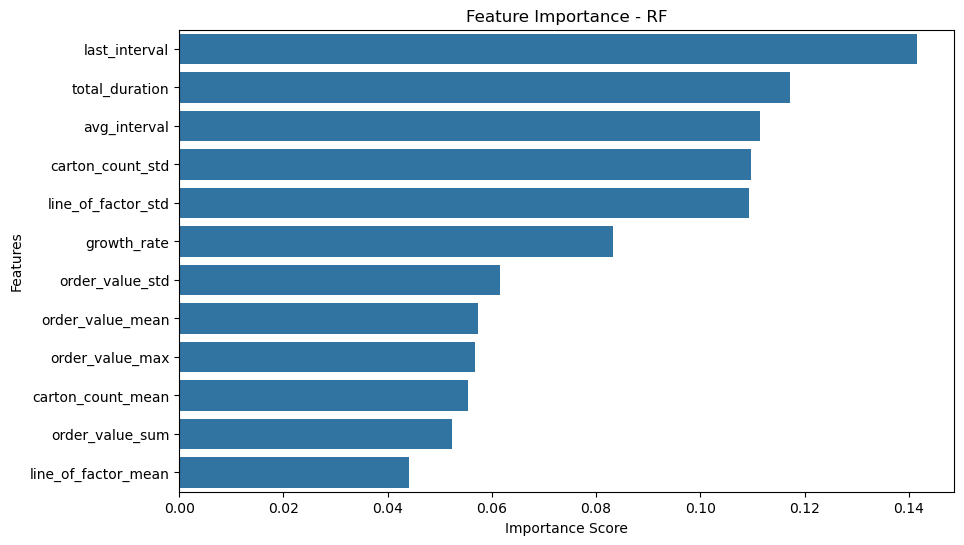

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df)
plt.title('Feature Importance - RF')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [26]:
# feature importance XG
xgb_importances = xgb_best.get_booster().get_score(importance_type='gain')

In [33]:
xgb_importances

{'f0': 0.8410065174102783,
 'f2': 0.34299227595329285,
 'f3': 0.3559087812900543,
 'f4': 0.7596940994262695,
 'f5': 1.0520745515823364,
 'f6': 0.47884708642959595,
 'f7': 1.1548506021499634,
 'f8': 1.224165678024292,
 'f10': 1.19221830368042,
 'f11': 0.5279089212417603}

In [32]:
feature_names = X_train.columns

In [34]:
feature_names

Index(['order_value_mean', 'order_value_sum', 'order_value_std',
       'order_value_max', 'carton_count_mean', 'carton_count_std',
       'line_of_factor_mean', 'line_of_factor_std', 'total_duration',
       'avg_interval', 'last_interval', 'growth_rate'],
      dtype='object')

In [36]:
mapped_importances = {feature_names[int(k[1:])]: v for k, v in xgb_importances.items()}

In [37]:
mapped_importances

{'order_value_mean': 0.8410065174102783,
 'order_value_std': 0.34299227595329285,
 'order_value_max': 0.3559087812900543,
 'carton_count_mean': 0.7596940994262695,
 'carton_count_std': 1.0520745515823364,
 'line_of_factor_mean': 0.47884708642959595,
 'line_of_factor_std': 1.1548506021499634,
 'total_duration': 1.224165678024292,
 'last_interval': 1.19221830368042,
 'growth_rate': 0.5279089212417603}

In [42]:
# dict to df
xgb_importance_df = pd.DataFrame({
    'Feature': list(mapped_importances.keys()),
    'Importance': list(mapped_importances.values())
})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

In [43]:
xgb_importance_df

,Feature,Importance
7,total_duration,1.224166
8,last_interval,1.192218
6,line_of_factor_std,1.154851
4,carton_count_std,1.052075
0,order_value_mean,0.841007
3,carton_count_mean,0.759694
9,growth_rate,0.527909
5,line_of_factor_mean,0.478847
2,order_value_max,0.355909
1,order_value_std,0.342992


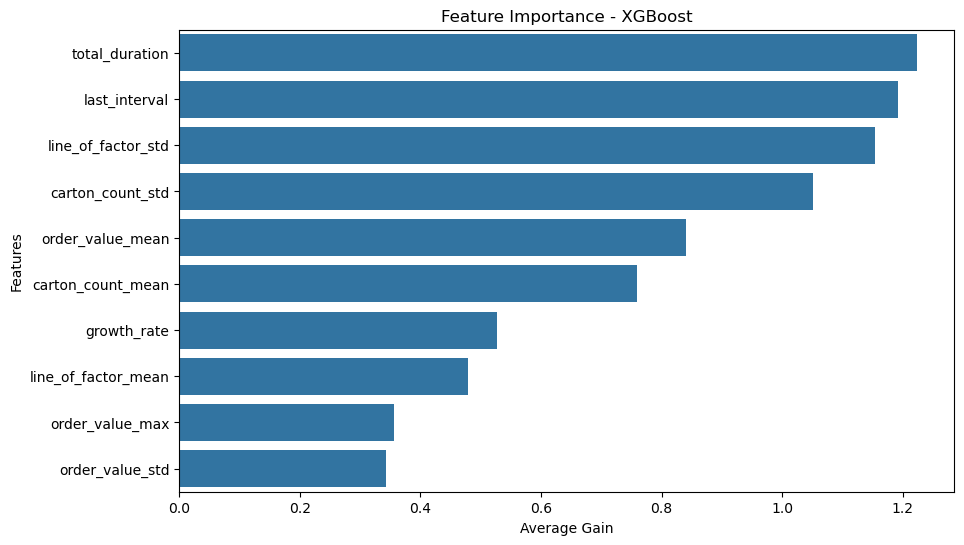

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df)
plt.title('Feature Importance - XGBoost')
plt.xlabel('Average Gain')
plt.ylabel('Features')
plt.show()
